In [73]:
from pathlib import Path
import sys

sys.path.append(r"D:\Users\Hannes\Documents\Python Code\nRTD\lib")

import wandb
from wandb_util import extract_run_savepoint
from nRTD.rtd_fitting_5 import RTDModule, RTDDataModule

import matplotlib.pyplot as plt
import matplotlib as mpl
import ICIW_Plots
import numpy as np
import torch



plt.style.use(["ICIWstyle", "ICIWlatex"])

In [74]:
# run_id = "jkwy4zpw" # with the shorter kernel times
run_id = "nx6hue2t"
name, ckpt_path = extract_run_savepoint(f"ice_ulm/HSA_MGA_nRTD/{run_id}")
model = RTDModule.load_from_checkpoint(ckpt_path)
# model.net.conv_layers[0].set_to_direct_response()

E1 = model.net.E[0].numpy()
E2 = model.net.E[1].numpy()
E3 = model.net.E[2].numpy()
E4 = model.net.E[3].numpy()
t1 = model.net.conv_layers[0].t_kernel.detach().numpy()
t2 = model.net.conv_layers[1].t_kernel.detach().numpy()
t3 = model.net.conv_layers[2].t_kernel.detach().numpy()
t4 = model.net.conv_layers[3].t_kernel.detach().numpy()

wandb:   1 of 1 files downloaded.  


In [75]:
print(I1 := np.trapz(E1, t1))
print(I2 := np.trapz(E2, t2))
print(I3 := np.trapz(E3, t3))


print(I4 := np.trapz(E4, t4))


print(I1 * I2 * I3 * I4)

0.9979831
0.9612422
0.80264574
0.9981084
0.76852435


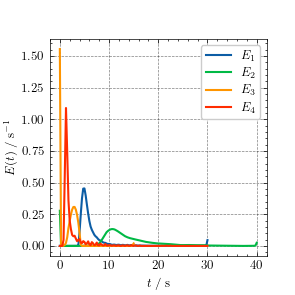

In [76]:
fig = ICIW_Plots.figure()
ax = ICIW_Plots.make_square_ax(
    fig,
    ax_width=5.5 * ICIW_Plots.cm2inch,
    left_h=0.5,
    xlabel=r"$t \;/\; \unit{\second}$",
    ylabel=r"$E(t)\;/\;\unit{\per\second}$",
)
ax.plot(t1, E1, label="$E_1$")
ax.plot(t2, E2, label="$E_2$")
ax.plot(t3, E3, label="$E_3$")
ax.plot(t4, E4, label="$E_4$")
ax.legend()

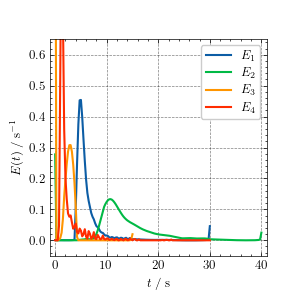

In [77]:
fig = ICIW_Plots.figure()
ax = ICIW_Plots.make_square_ax(
    fig,
    ax_width=5.5 * ICIW_Plots.cm2inch,
    left_h=0.5,
    xlabel=r"$t \;/\; \unit{\second}$",
    ylabel=r"$E(t)\;/\;\unit{\per\second}$",
    xlim=(-1, 41),
    ylim=(-0.05, 0.65),
)
ax.plot(t1, E1, label="$E_1$")
ax.plot(t2, E2, label="$E_2$")
ax.plot(t3, E3, label="$E_3$")
ax.plot(t4, E4, label="$E_4$")
ax.legend()

In [78]:
t_out = (0.0, 120.0)
t_in = (0.0, 5.0)
t_halfperiod = t_out[1] - t_out[0]
n_out = int(4 * (t_out[1] - t_out[0]) + 1)
n_in = int(4 * (t_in[1] - t_in[0]) + 1)
delta_t_out = (t_out[1] - t_out[0]) / (n_out - 1)
automated_switching_times = np.full((20,), t_halfperiod)
switching_times_total_system = np.insert(automated_switching_times, 0, 7.5 - 1.0)
switching_times_total_system = np.cumsum(switching_times_total_system)

data_total_system = RTDDataModule(
    batch_size=32,
    data_file=Path(
        r"D:\Users\Hannes\Documents\Python Code\nRTD\Experiments\HSA_004\data\MGA-E-10032025_30ml-min_1atm_TotalSystem.npz"
    ),
    switching_times=switching_times_total_system,
    t_range_in=t_in,
    n_in=n_in,
    t_range_out=t_out,
    n_out=n_out,
    switch_delay=1.0,
)

In [79]:
data_total_system.setup("eval")

Setup


In [80]:
data_total_system.y.shape

torch.Size([40, 1, 481])

In [81]:
res = model(data_total_system.x.to(torch.float), data_total_system.t_in.to(torch.float))

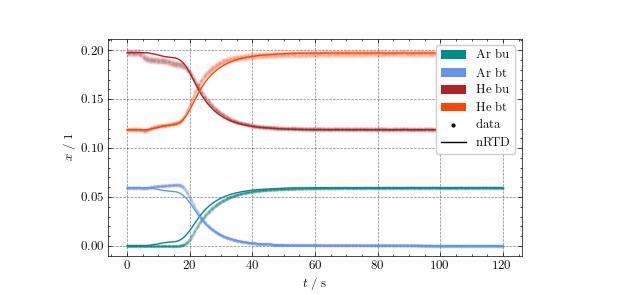

In [93]:
fig = ICIW_Plots.figure(layout="double_column")
ax = ICIW_Plots.make_rect_ax(
    fig,
    ax_height=5.5 * ICIW_Plots.cm2inch,
    ax_width=10.5 * ICIW_Plots.cm2inch,
    xlabel=r"$t \;/\; \unit{\second}$",
    ylabel=r"$x \;/\; \num{1}$",
)
ax.scatter(
    data_total_system.t_out[::4, ...],
    data_total_system.y[::4, ...],
    alpha=0.02,
    s=2,
    color="darkcyan",
    label=r"\ce{Ar} bu",
)
ax.scatter(
    data_total_system.t_out[2::4, ...],
    data_total_system.y[2::4, ...],
    alpha=0.02,
    s=2,
    color="cornflowerblue",
    label=r"\ce{He} bu",
)
ax.scatter(
    data_total_system.t_out[1::4, ...],
    data_total_system.y[1::4, ...],
    alpha=0.02,
    s=2,
    color="firebrick",
    label=r"\ce{Ar} bt",
)
ax.scatter(
    data_total_system.t_out[3::4, ...],
    data_total_system.y[3::4, ...],
    alpha=0.02,
    s=2,
    color="orangered",
    label=r"\ce{He} bt",
)

ax.plot(
    res[1][0, ...].detach().numpy(),
    res[0][0, 0, :].detach().numpy(),
    lw=1,
    color="darkcyan",
)
ax.plot(
    res[1][2, ...].detach().numpy(),
    res[0][2, 0, :].detach().numpy(),
    lw=1,
    color="cornflowerblue",
)
ax.plot(
    res[1][1, ...].detach().numpy(),
    res[0][1, 0, :].detach().numpy(),
    lw=1,
    color="firebrick",
)
ax.plot(
    res[1][3, ...].detach().numpy(),
    res[0][3, 0, :].detach().numpy(),
    lw=1,
    color="orangered",
)

legend_handles = [
    mpl.patches.Patch(facecolor="darkcyan"),
    mpl.patches.Patch(facecolor="cornflowerblue"),
    mpl.patches.Patch(facecolor="firebrick"),
    mpl.patches.Patch(facecolor="orangered"),
    plt.Line2D([0], [0], color="None", marker="o", markerfacecolor="k", markersize=2),
    plt.Line2D([0], [0], color="k", lw=1),
]
legend_names = [
    r"$\ce{Ar} \text{ bu}$",
    r"$\ce{Ar} \text{ bt}$",
    r"$\ce{He} \text{ bu}$",
    r"$\ce{He} \text{ bt}$",
    r"$\text{data}$",
    r"$\text{nRTD}$",
]

ax.legend(legend_handles, legend_names, loc="upper right")

In [83]:
normalized_signals = (data_total_system.y - data_total_system.x[:, :, [0]]) / (
    data_total_system.x[:, :, [-1]] - data_total_system.x[:, :, [0]]
)
normalized_res = (res[0] - data_total_system.x[:, :, [0]]) / (
    data_total_system.x[:, :, [-1]] - data_total_system.x[:, :, [0]]
)
print(data_total_system.y.shape)
print(normalized_signals.shape)

torch.Size([40, 1, 481])
torch.Size([40, 1, 481])


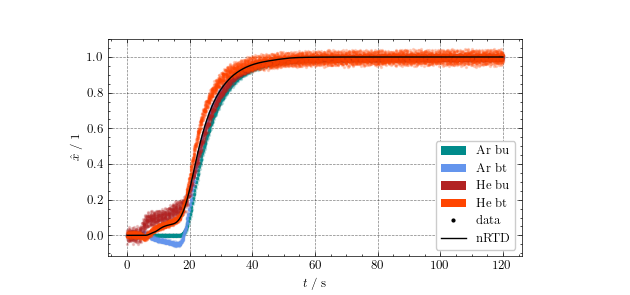

In [96]:
fig = ICIW_Plots.figure(layout="double_column")
ax = ICIW_Plots.make_rect_ax(
    fig,
    ax_height=5.5 * ICIW_Plots.cm2inch,
    ax_width=10.5 * ICIW_Plots.cm2inch,
    xlabel=r"$t \;/\; \unit{\second}$",
    ylabel=r"$\hat{x} \;/\; \num{1}$",
)
ax.scatter(
    data_total_system.t_out[::4, ...],
    normalized_signals[::4, ...],
    alpha=0.2,
    s=2,
    label=r"\ce{Ar} bu",
    color="darkcyan",
)
ax.scatter(
    data_total_system.t_out[2::4, ...],
    normalized_signals[2::4, ...],
    alpha=0.2,
    s=2,
    label=r"\ce{He} bu",
    color="cornflowerblue",
)
ax.scatter(
    data_total_system.t_out[1::4, ...],
    normalized_signals[1::4, ...],
    alpha=0.2,
    s=2,
    label=r"\ce{Ar} bt",
    color="firebrick",
)
ax.scatter(
    data_total_system.t_out[3::4, ...],
    normalized_signals[3::4, ...],
    alpha=0.2,
    s=2,
    label=r"\ce{He} bt",
    color="orangered",
)
ax.plot(
    res[1][0, ...].detach().numpy(),
    normalized_res[0, 0, :].detach().numpy(),
    # lw=0,
    color="black",
    label="nRTD",
    lw=1,
)
legend_handles = [
    mpl.patches.Patch(facecolor="darkcyan"),
    mpl.patches.Patch(facecolor="cornflowerblue"),
    mpl.patches.Patch(facecolor="firebrick"),
    mpl.patches.Patch(facecolor="orangered"),
    plt.Line2D([0], [0], color="None", marker="o", markerfacecolor="k", markersize=2),
    plt.Line2D([0], [0], color="k", lw=1),
]
legend_names = [
    r"$\ce{Ar} \text{ bu}$",
    r"$\ce{Ar} \text{ bt}$",
    r"$\ce{He} \text{ bu}$",
    r"$\ce{He} \text{ bt}$",
    r"$\text{data}$",
    r"$\text{nRTD}$",
]

ax.legend(legend_handles, legend_names)